<a href="https://colab.research.google.com/github/AmatHub21/Latihan-Esmeble_Sklearn_byest-/blob/main/EVALUASI%20MODEL%20KLASIFIKASI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# 1. Generate dataset (Imbalanced: 90% Class 0, 10% Class 1)
X, y = make_classification(n_samples=1000, n_features=20,
                           weights=[0.9, 0.1], random_state=42)

# 2. Split data dengan stratify agar proporsi kelas terjaga
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 4. Hitung metrik
print("="*50)
print("EVALUASI MODEL")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("(Format: [[TN, FP], [FN, TP]])")

# 6. Classification Report (Lengkap)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

# 7. Interpretasi manual dari Confusion Matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nInterpretasi:")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

EVALUASI MODEL
Accuracy:  0.9533
Precision: 0.8696
Recall:    0.6452
F1-Score:  0.7407

Confusion Matrix:
[[266   3]
 [ 11  20]]
(Format: [[TN, FP], [FN, TP]])

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.96      0.99      0.97       269
     Class 1       0.87      0.65      0.74        31

    accuracy                           0.95       300
   macro avg       0.91      0.82      0.86       300
weighted avg       0.95      0.95      0.95       300


Interpretasi:
True Negatives:  266
False Positives: 3
False Negatives: 11
True Positives:  20


AUC Score: 0.9076


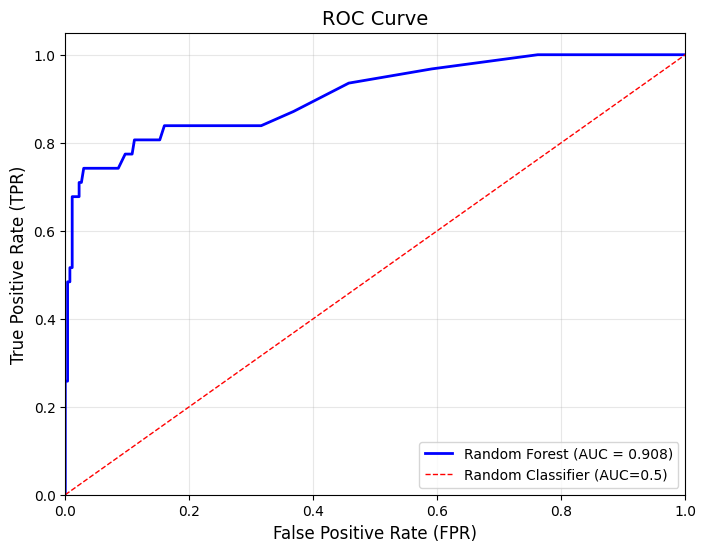

Optimal threshold (Youden's J): 0.3300


In [3]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Mengambil probabilitas kelas positif (bukan prediksi label)
y_proba = model.predict_proba(X_test)[:, 1]

# Hitung ROC curve dan AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
print(f"AUC Score: {auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, 'b', linewidth=2, label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier (AUC=0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC Curve', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Cari threshold optimal menggunakan Youden's J statistic
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold (Youden's J): {optimal_threshold:.4f}")

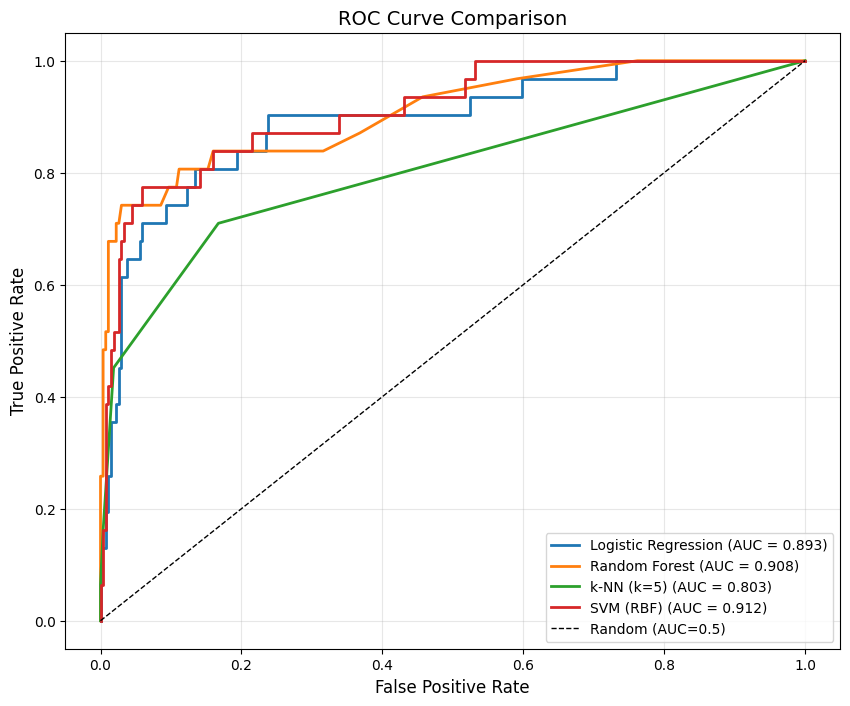

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Definisikan daftar model
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'k-NN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)': SVC(probability=True, random_state=42)
}

plt.figure(figsize=(10,8))

for name, model_obj in models.items():
    model_obj.fit(X_train, y_train)
    y_proba = model_obj.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [5]:
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold

# 1. HOLD-OUT VALIDATION (Diulang 10x untuk melihat varians)
scores_holdout = []
for i in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=i)
    clf = RandomForestClassifier(random_state=42)
    clf.fit(X_tr, y_tr)
    scores_holdout.append(clf.score(X_te, y_te))

print(f"Hold-out Mean Accuracy: {np.mean(scores_holdout):.4f} (+/- {np.std(scores_holdout):.4f})")

# 2. STANDARD K-FOLD
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores_kfold = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
print(f"k-Fold (k=5) Mean: {scores_kfold.mean():.4f}")

# 3. STRATIFIED K-FOLD (Sangat disarankan untuk data tidak seimbang)
strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_strat = cross_val_score(model, X, y, cv=strat_kfold, scoring='accuracy')
print(f"Stratified k-Fold Mean: {scores_strat.mean():.4f}")

Hold-out Mean Accuracy: 0.9487 (+/- 0.0093)
k-Fold (k=5) Mean: 0.9540
Stratified k-Fold Mean: 0.9530


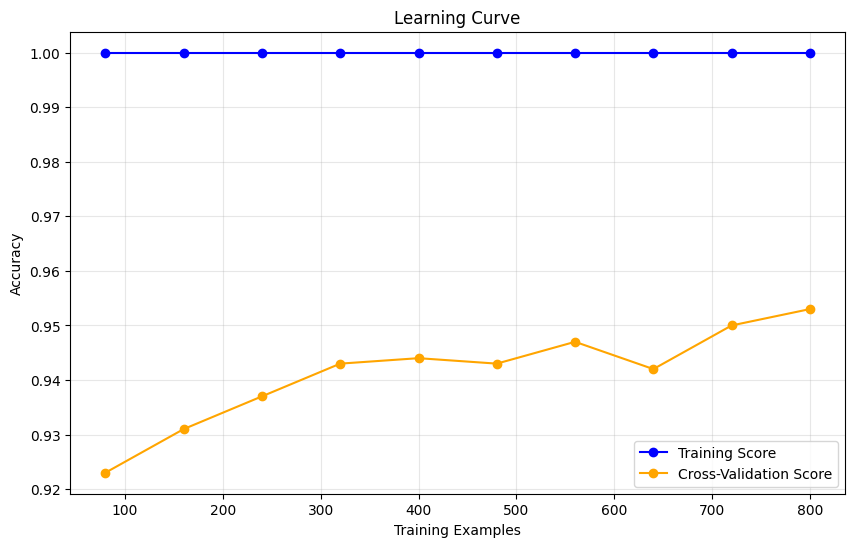

MODEL GOOD: Skor Training dan Validasi konvergen (berdekatan).


In [6]:
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

train_sizes, train_scores, test_scores = learning_curve(
    RandomForestClassifier(random_state=42), X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy', n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-Validation Score')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

# Diagnosa singkat
gap = train_mean[-1] - test_mean[-1]
if gap > 0.1:
    print("MODEL OVERFITTING: Skor Training jauh lebih tinggi dari Validasi.")
elif gap < -0.05:
    print("MODEL UNDERFITTING: Performa buruk pada keduanya.")
else:
    print("MODEL GOOD: Skor Training dan Validasi konvergen (berdekatan).")